# Raul vs mistsim: `main` versus PR 12

Compares Raul's reference simulator against mistsim run under two
environments: `main` (croissant 5.1.4) and this branch (croissant
v5.3.0.dev2, PR 12).

**Run this notebook twice** — once under the `mistsim (croissant
5.1.4)` kernel, once under the project kernel. It tags its own output
by the croissant revision it detects, and the comparison section
renders whichever tagged results exist. The second run is the complete
artifact.

The two environments differ in croissant, s2fft **and** jax together;
they cannot be separated cheaply because croissant 5.1.4 and PyPI
s2fft both require `jax<0.6`. This notebook therefore measures *`main`
versus PR 12*, not the pole-of-date fix in isolation.


In [1]:
import json
from pathlib import Path

import jax

jax.config.update("jax_enable_x64", True)

import importlib.metadata as md

import astropy.units as u
import croissant as cro
import h5py
import healpy as hp
import matplotlib.pyplot as plt
import numpy as np
from astropy.coordinates import EarthLocation
from astropy.io import fits
from astropy.time import Time

import mistsim as ms

%matplotlib inline

REPO = Path("/home/christian/Documents/research/MIST/mistsim")
DATA_DIR = REPO / "data"
OUT_DIR = REPO / "notebooks/sim_comparisons/results"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Astronomical azimuth of the beam X-axis. The FEKO beam has
# phi=0=North, so 0 is correct; see beam.py (beam_rot = az_rot - 90).
BEAM_AZ_ROT = 0

# This notebook never writes to data/. beam.npz there is a live
# mapmaking input (mars-lake-dip in runs.yaml).
WRITE_SHARED_INPUTS = False

NSIDE = 128
SIM_LMAX = 100

TESTS = {
    0: "MARS / with mountains",
    1: "MARS / no mountains",
    2: "North Pole / no mountains",
}


In [2]:
def croissant_tag():
    """Machine tag and human label for the installed croissant.

    The v5.3.0.dev2 tag still reports __version__ == "5.2.1", so the
    version string alone cannot distinguish the environments. Prefer
    the git revision the installer recorded; fall back to probing for
    eq2cirs, which exists only after the bump.
    """
    version = md.version("croissant-sim")
    rev = None
    try:
        raw = md.distribution("croissant-sim").read_text(
            "direct_url.json"
        )
        if raw:
            rev = json.loads(raw).get("vcs_info", {}).get("commit_id")
    except Exception:
        rev = None
    tag = f"{version}+git{rev[:7]}" if rev else version
    is_new = hasattr(cro.rotations, "eq2cirs")
    label = (
        "PR 12 (croissant v5.3.0.dev2)"
        if is_new
        else "main (croissant 5.1.4)"
    )
    return tag, label


TAG, LABEL = croissant_tag()
print(f"TAG   = {TAG}")
print(f"LABEL = {LABEL}")
print(f"jax   = {jax.__version__}")


TAG   = 5.2.1+gitd972c5f
LABEL = PR 12 (croissant v5.3.0.dev2)
jax   = 0.11.1


In [3]:
def read_raul(path):
    with h5py.File(path, "r") as hf:
        return (
            np.array(hf["lst"]),
            np.array(hf["freq"]),
            np.array(hf["ant_temp"]),
        )


paths = {
    0: "20260215_for_christian/antenna_temperature_20260215_test1.hdf5",
    1: "20260220_for_christian/antenna_temperature_20260220_test1.hdf5",
    2: "20260220_for_christian/antenna_temperature_20260220_test2.hdf5",
}

raul, lsts = {}, {}
freqs = None
for k, rel in paths.items():
    lst_k, freq_k, temp_k = read_raul(DATA_DIR / rel)
    if freqs is None:
        freqs = freq_k
    assert np.allclose(freq_k, freqs), f"freq mismatch in test {k}"
    assert temp_k.shape == (lst_k.size, freqs.size), (
        f"test {k}: got {temp_k.shape}"
    )
    raul[k], lsts[k] = temp_k, lst_k

# Tests 0 and 1 share a MARS LST grid; test 2 is the North Pole grid.
assert np.allclose(lsts[0], lsts[1])
print(f"freqs {freqs.shape}: {freqs[0]:.0f}-{freqs[-1]:.0f} MHz")
for k in raul:
    print(f"test {k}: {raul[k].shape}, LST "
          f"{lsts[k][0]:.2f}-{lsts[k][-1]:.2f} hr")


freqs (86,): 40-125 MHz
test 0: (241, 86), LST 0.08-23.98 hr
test 1: (241, 86), LST 0.08-23.98 hr
test 2: (241, 86), LST 0.03-23.93 hr


In [4]:
def load_haslam():
    path = (
        DATA_DIR
        / "20260215_for_christian/haslam408_ds_Remazeilles2014.fits"
    )
    with fits.open(path) as hdul:
        return hdul[1].data["TEMPERATURE"].ravel()


def scale_map(m, freqs, beta=-2.55, f0=408, tcmb=2.725):
    scale = (freqs / f0) ** beta
    return (m - tcmb)[None, :] * scale[:, None] + tcmb


haslam = hp.ud_grade(load_haslam(), NSIDE, order_in="RING")
haslam = scale_map(haslam, freqs)
sky_model = ms.Sky(haslam, freqs, sampling="healpix", coord="galactic")
print(f"sky {sky_model.data.shape}")


sky (86, 196608)


data/beam.npz left untouched (WRITE_SHARED_INPUTS=False)


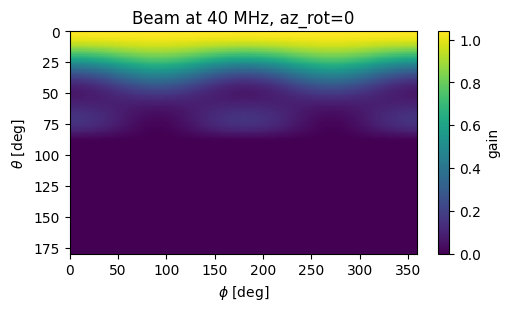

In [5]:
d = np.load(DATA_DIR / "feko_beam.npz")
theta = d["theta"]
assert theta.max() <= np.pi * (1 + 1e-6), (
    "feko_beam.npz must store theta in radians"
)

fix = np.isin(d["freqs"] / 1e6, freqs)
gain_above = d["gain"][fix]
assert np.allclose(d["freqs"][fix] / 1e6, freqs)

# Extend theta to 180 deg with zero gain below the horizon.
gain = np.concatenate(
    (gain_above, np.zeros_like(gain_above[:, :-1, :])), axis=1
)
theta_full = np.concatenate(
    (theta, np.deg2rad(np.arange(91, 181)))
)

horizon = (theta_full <= np.deg2rad(80))[:, None]
beam_mtn = ms.Beam(
    gain, freqs, sampling="mwss", horizon=horizon,
    beam_az_rot=BEAM_AZ_ROT,
)
beam_flat = ms.Beam(
    gain, freqs, sampling="mwss", horizon=None,
    beam_az_rot=BEAM_AZ_ROT,
)
beams = {0: beam_mtn, 1: beam_flat, 2: beam_flat}

if WRITE_SHARED_INPUTS:
    np.savez(
        DATA_DIR / "beam.npz",
        freqs=d["freqs"][fix] / 1e6, phi=d["phi"],
        theta=theta_full, gain=gain,
    )
else:
    print("data/beam.npz left untouched (WRITE_SHARED_INPUTS=False)")

plt.figure(figsize=(5, 3), constrained_layout=True)
plt.imshow(gain[0], aspect="auto", interpolation="none",
           extent=[0, 359, 180, 0])
plt.colorbar(label="gain")
plt.title(f"Beam at {freqs[0]:.0f} MHz, az_rot={BEAM_AZ_ROT}")
plt.xlabel(r"$\phi$ [deg]")
plt.ylabel(r"$\theta$ [deg]")
plt.show()


In [6]:
mars = EarthLocation.from_geodetic(-90.74750, 79.41833, height=150)
npole = EarthLocation.from_geodetic(0, 90, height=0)
locs = {0: mars, 1: mars, 2: npole}


def lst_to_time(lst_arr, t0):
    """Convert an array of LST in hours to astropy Times."""
    lst_ref = t0.sidereal_time("mean").hour
    return t0 + (lst_arr - lst_ref) / 24 * u.sday


times = {}
for k, loc in locs.items():
    t0 = Time("2022-07-17 00:00", location=loc)
    times[k] = lst_to_time(lsts[k], t0)
    got = times[k].sidereal_time("mean").hour
    assert np.allclose(got, lsts[k]), f"LST mismatch in test {k}"
print("LST round-trip OK for all three tests")


LST round-trip OK for all three tests


In [7]:
cache_path = OUT_DIR / f"raul_cmp_{TAG}.npz"

if cache_path.exists():
    print(f"Loading cached {cache_path.name}")
    c = np.load(cache_path, allow_pickle=True)
    mine = {k: c[f"test{k}"] for k in TESTS}
else:
    mine = {}
    for k in TESTS:
        print(f"Simulating test {k}: {TESTS[k]}")
        sim = ms.Simulator(
            beams[k], sky_model, times[k].jd, freqs,
            locs[k].lon.deg, locs[k].lat.deg,
            alt=locs[k].height.value, lmax=SIM_LMAX, Tgnd=0,
        )
        tant = sim.sim()
        fgnd = sim.beam.compute_fgnd()
        mine[k] = np.asarray(
            cro.simulator.correct_ground_loss(tant, fgnd, 0)
        )
    np.savez(
        cache_path,
        test0=mine[0], test1=mine[1], test2=mine[2],
        lst0=lsts[0], lst2=lsts[2], freqs=freqs,
        tag=TAG, label=LABEL, beam_az_rot=BEAM_AZ_ROT,
    )
    print(f"Wrote {cache_path}")

for k in TESTS:
    assert mine[k].shape == raul[k].shape, (
        f"test {k}: {mine[k].shape} vs Raul {raul[k].shape}"
    )
print("All three waterfalls match Raul's shape")


Loading cached raul_cmp_5.2.1+gitd972c5f.npz
All three waterfalls match Raul's shape
